In [34]:
#Importing the libs required
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_style('whitegrid')

In [35]:
#loading the dataset
df = pd.read_csv("/content/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [36]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [37]:
#Shows no. of rows and columns
print(df.shape)

(1000, 9)


In [38]:
#shows no. of columns
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [39]:
#show data typess and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [40]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

In [41]:
#removing duplicates
df.drop_duplicates(inplace=True)

In [42]:
#shows arithmatic values
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [43]:
#shows mean
df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [44]:
#shows median
df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [45]:
#shows mode
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [46]:
#shows std. deviation
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [47]:
#converting date,month and quater columns
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

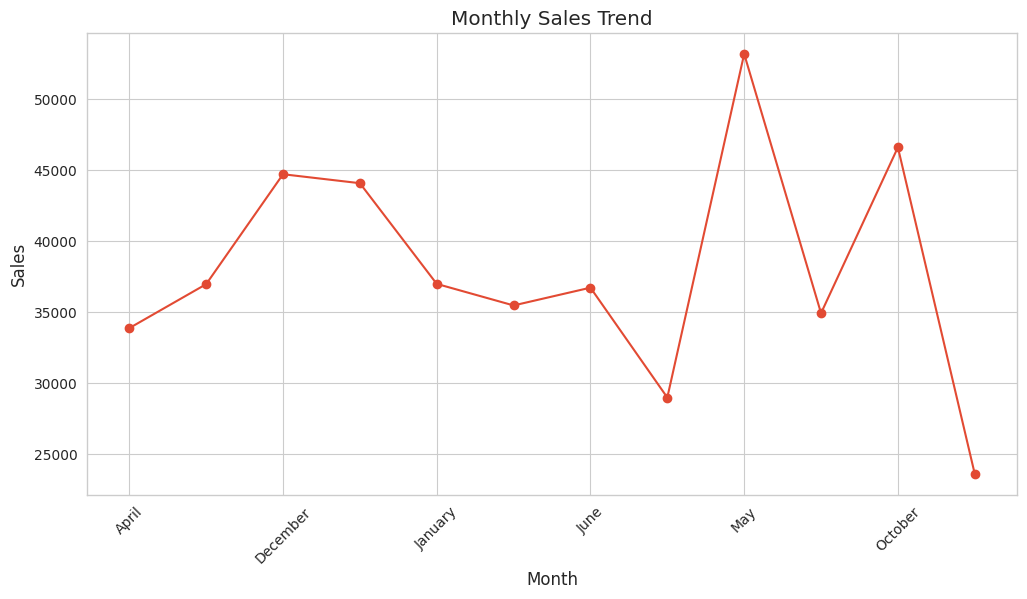

In [48]:
# shows monthly Sales Trend
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

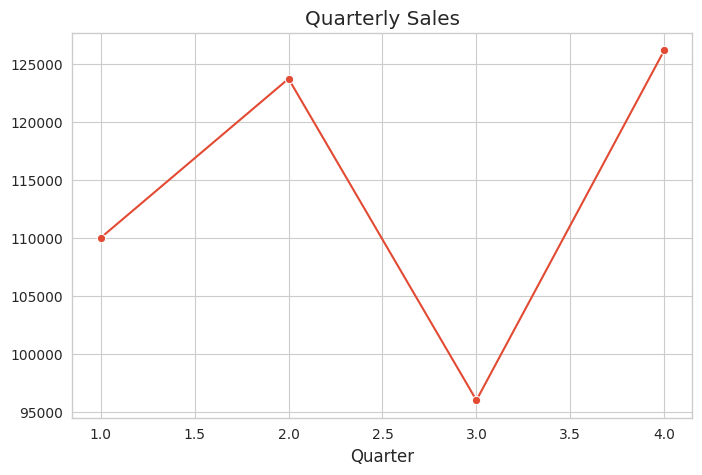

In [49]:
#Identifying highest performing quarter

quarter_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(8,5))

sns.lineplot(x=quarter_sales.index,
             y=quarter_sales.values,
             marker="o")

plt.title("Quarterly Sales")

plt.show()

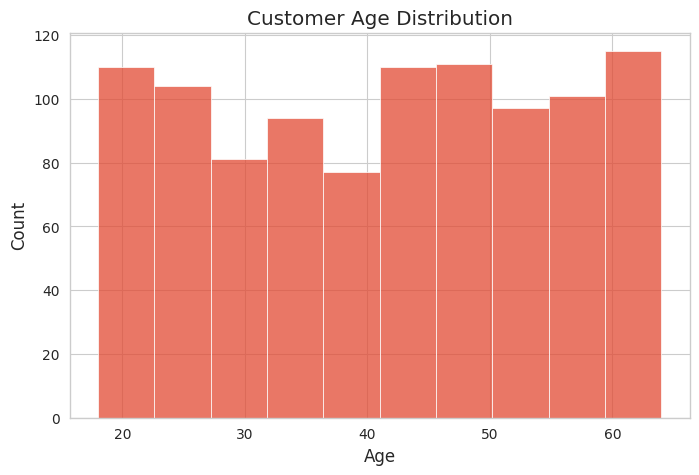

In [50]:
#shows which age group shops the most
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10)

plt.title("Customer Age Distribution")

plt.show()

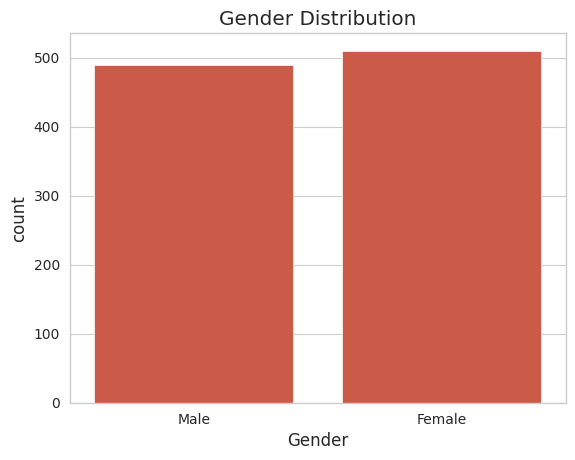

In [51]:
#shows total no. of male and female customers
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

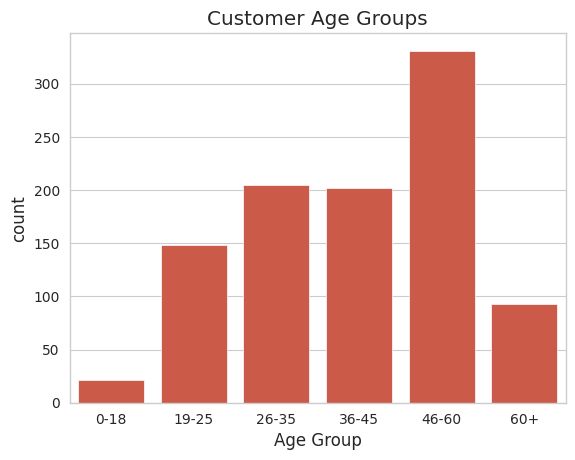

In [52]:
#shows most active customers age grp
bins = [0,18,25,35,45,60,100]

labels = ["0-18","19-25","26-35","36-45","46-60","60+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

sns.countplot(x="Age Group", data=df)

plt.title("Customer Age Groups")

plt.show()

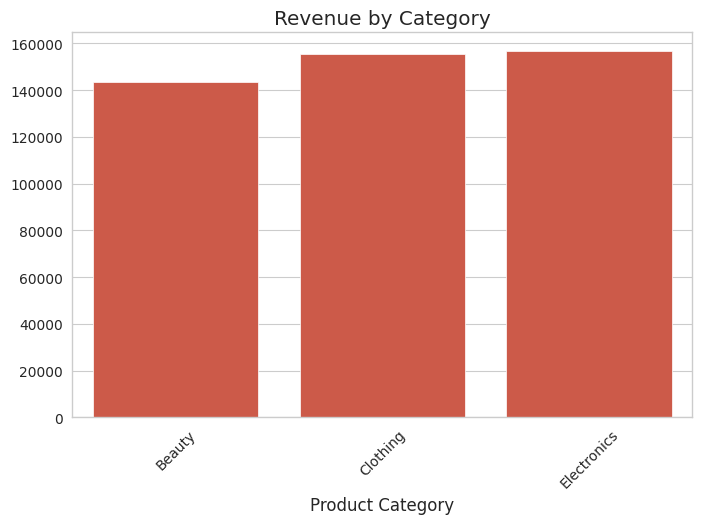

In [53]:
#revenue by category
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index,
            y=category_sales.values)

plt.xticks(rotation=45)

plt.title("Revenue by Category")

plt.show()

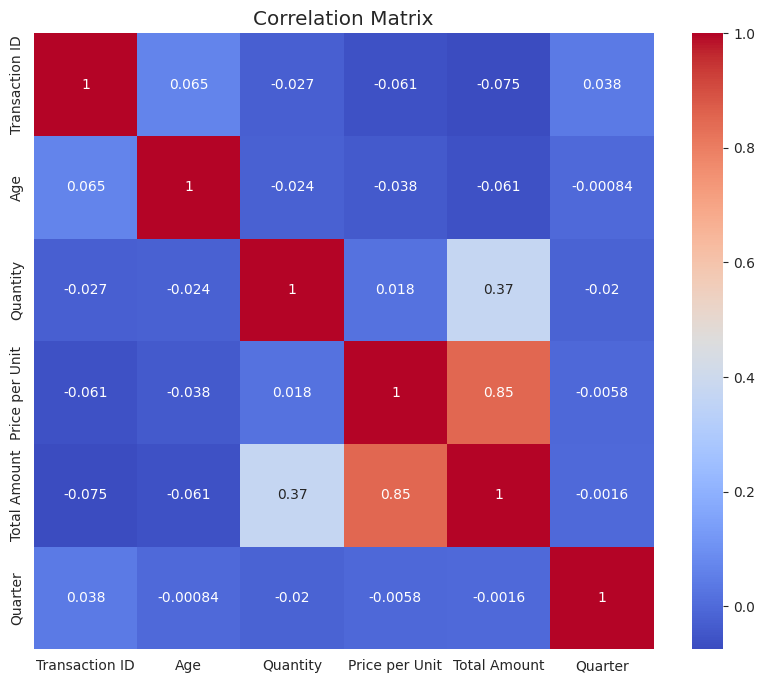

In [54]:
#shows relation between numerical values
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

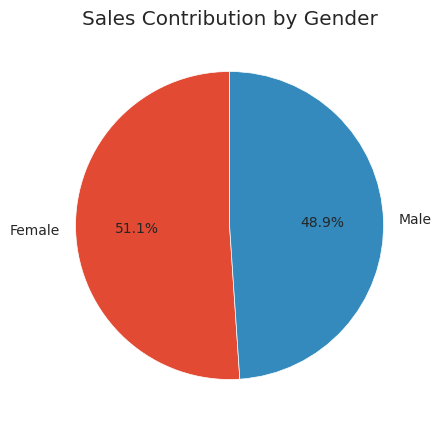

In [55]:
#sales by gender
gender_sales = df.groupby("Gender")["Total Amount"].sum()

plt.figure(figsize=(6,5))

plt.pie(gender_sales,
        labels=gender_sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Sales Contribution by Gender")

plt.show()